# Telecom churn — feature engineering & modeling

Builds on EDA in [`main.ipynb`](main.ipynb) / takeaways in [`residue.ipynb`](residue.ipynb).

## Route chosen

| Choice                      | Why                                       | Counterpart        |
| :-------------------------- | :---------------------------------------- | :----------------- | ----------------------------------------------------------------------------------------------- | ------------------- |
| **Random Forest (primary)** | Weak linear $                             | r                  | $ with churn in EDA; trees capture interactions (e.g. handset age × usage drop) without scaling | Logistic regression |
| **Lean ~30 features**       | MOU/revenue families are highly redundant | All ~99 columns    |
| **No SMOTE**                | Target already ~50/50                     | Oversampling       |
| **sklearn only**            | Enough for RF + LR in a course env        | XGBoost / LightGBM |

**How to read the counterpart:** if RF AUC ≫ LR, cite non-linearity; if close, LR coefficients are easier for the write-up.

> Note: churn ≈ 50/50 may be a **balanced extract**, not the carrier’s raw population rate. Accuracy is usable here; real-world rates are often much lower.


## 1. Setup & load / join


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")
%matplotlib inline

RANDOM_STATE = 42

In [2]:
client = pd.read_csv("../data/telecom/Client.csv")
record = pd.read_csv("../data/telecom/Record.csv")
df = record.merge(client, on="Customer_ID", how="inner")
print("Merged shape:", df.shape)
print("Churn rate:", df["churn"].mean().round(4)) # type: ignore

Merged shape: (100000, 100)
Churn rate: 0.4956


## 2. Feature engineering

1. Drop `Customer_ID`
2. Fix negatives (`eqpdays`)
3. Derive a few explainable features
4. Keep a lean numeric + categorical set (EDA-driven)
5. Stratified split; clip heavy tails using **train** percentiles only


In [3]:
# --- quality fixes & derived features (pre-split safe transforms) ---
work = df.copy()
work["eqpdays"] = work["eqpdays"].clip(lower=0)

eps = 1e-6
work["mou_decline_flag"] = (work["change_mou"] < 0).astype("float")
work["overage_ratio"] = work["ovrrev_Mean"] / (work["totmrc_Mean"].abs() + eps)

# Lean feature set from EDA (actionable + non-redundant windows)
NUMERIC_FEATURES = [
    "eqpdays",
    "hnd_price",
    "phones",
    "models",
    "months",
    "mou_Mean",
    "rev_Mean",
    "totmrc_Mean",
    "change_mou",
    "change_rev",
    "avg3mou",  # one rolling window; skip avgmou/avg6/tot* to cut redundancy
    "drop_vce_Mean",
    "custcare_Mean",
    "ovrmou_Mean",
    "ovrrev_Mean",
    "mou_decline_flag",
    "overage_ratio",
]

CATEGORICAL_FEATURES = [
    "asl_flag",
    "creditcd",
    "new_cell",
    "refurb_new",
    "dualband",
    "hnd_webcap",
    "area",
    "prizm_social_one",
]

# Dropped as sparse / weak for proposal: numbcars, dwllsize, HHstatin, ownrent, lor, income, ...
FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES
missing = [c for c in FEATURE_COLS if c not in work.columns]
assert not missing, f"Missing columns: {missing}"

X = work[FEATURE_COLS].copy()
y = work["churn"].astype(int)

# Categoricals as string with explicit Missing (imputer also handles residual nulls)
for col in CATEGORICAL_FEATURES:
    X[col] = X[col].astype("string").fillna("Missing").astype(str)

print(f"Features: {len(FEATURE_COLS)} ({len(NUMERIC_FEATURES)} numeric, {len(CATEGORICAL_FEATURES)} categorical)")
print("Numeric:", NUMERIC_FEATURES)
print("Categorical:", CATEGORICAL_FEATURES)

Features: 25 (17 numeric, 8 categorical)
Numeric: ['eqpdays', 'hnd_price', 'phones', 'models', 'months', 'mou_Mean', 'rev_Mean', 'totmrc_Mean', 'change_mou', 'change_rev', 'avg3mou', 'drop_vce_Mean', 'custcare_Mean', 'ovrmou_Mean', 'ovrrev_Mean', 'mou_decline_flag', 'overage_ratio']
Categorical: ['asl_flag', 'creditcd', 'new_cell', 'refurb_new', 'dualband', 'hnd_webcap', 'area', 'prizm_social_one']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train churn rate:", y_train.mean().round(4), "| Test:", y_test.mean().round(4))

# Train-only winsorization for heavy-tailed change_* columns
CLIP_COLS = ["change_mou", "change_rev", "overage_ratio"]
clip_bounds = {}
for col in CLIP_COLS:
    lo, hi = X_train[col].quantile([0.01, 0.99])
    clip_bounds[col] = (lo, hi)
    X_train[col] = X_train[col].clip(lo, hi)
    X_test[col] = X_test[col].clip(lo, hi)

print("Train-fitted clip bounds (1st–99th pct):")
for col, (lo, hi) in clip_bounds.items():
    print(f"  {col}: [{lo:.4f}, {hi:.4f}]")

Train: (80000, 25) Test: (20000, 25)
Train churn rate: 0.4956 | Test: 0.4956
Train-fitted clip bounds (1st–99th pct):
  change_mou: [-841.2975, 748.7850]
  change_rev: [-104.8283, 121.3412]
  overage_ratio: [0.0000, 3.9075]


## 3. Preprocessing pipelines

- **Numeric:** median impute (+ standard scale for logistic regression)
- **Categorical:** constant `"Missing"` + one-hot (`handle_unknown="ignore"`)


In [5]:
def make_ohe():
    # sklearn >=1.2 uses sparse_output; fall back for older envs
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_categorical():
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", make_ohe()),
        ]
    )


def make_preprocessor(numeric_pipe):
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, NUMERIC_FEATURES),
            ("cat", make_categorical(), CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )


numeric_rf = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)
numeric_lr = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
lr_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

rf_pipe = Pipeline(
    steps=[
        ("pre", make_preprocessor(numeric_rf)),
        ("model", rf_clf),
    ]
)
lr_pipe = Pipeline(
    steps=[
        ("pre", make_preprocessor(numeric_lr)),
        ("model", lr_clf),
    ]
)

print("Pipelines ready.")


Pipelines ready.


## 4. Train & compare — Random Forest (primary) vs Logistic Regression (counterpart)


In [6]:
def evaluate(name, pipe, X_te, y_te):
    proba = pipe.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_te, pred),
        "roc_auc": roc_auc_score(y_te, proba),
        "precision": precision_score(y_te, pred),
        "recall": recall_score(y_te, pred),
        "f1": f1_score(y_te, pred),
    }
    return metrics, pred, proba


print("Fitting Random Forest...")
rf_pipe.fit(X_train, y_train)
rf_metrics, rf_pred, rf_proba = evaluate("Random Forest", rf_pipe, X_test, y_test)

print("Fitting Logistic Regression...")
lr_pipe.fit(X_train, y_train)
lr_metrics, lr_pred, lr_proba = evaluate("Logistic Regression", lr_pipe, X_test, y_test)

metrics_df = pd.DataFrame([rf_metrics, lr_metrics]).set_index("model")
display(metrics_df.round(4))

print("\n=== Random Forest (primary) ===")
print(classification_report(y_test, rf_pred, digits=3))
print("=== Logistic Regression (counterpart) ===")
print(classification_report(y_test, lr_pred, digits=3))

Fitting Random Forest...
Fitting Logistic Regression...


,accuracy,roc_auc,precision,recall,f1
model,,,,,
Random Forest,0.6133,0.6658,0.5990,0.6645,0.6301
Logistic Regression,0.5802,0.6090,0.5762,0.5786,0.5774



=== Random Forest (primary) ===
              precision    recall  f1-score   support

           0      0.631     0.563     0.595     10088
           1      0.599     0.665     0.630      9912

    accuracy                          0.613     20000
   macro avg      0.615     0.614     0.613     20000
weighted avg      0.615     0.613     0.612     20000

=== Logistic Regression (counterpart) ===
              precision    recall  f1-score   support

           0      0.584     0.582     0.583     10088
           1      0.576     0.579     0.577      9912

    accuracy                          0.580     20000
   macro avg      0.580     0.580     0.580     20000
weighted avg      0.580     0.580     0.580     20000



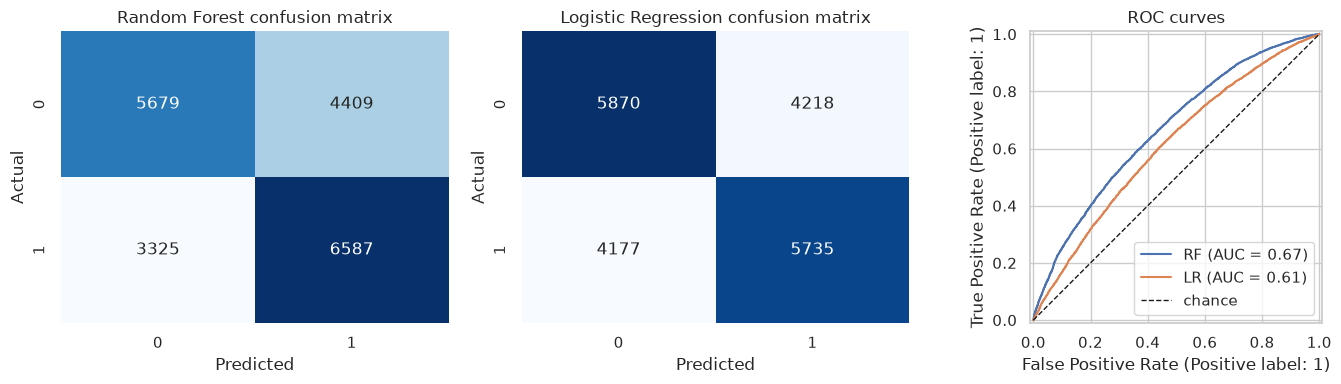

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, name, pred in [
    (axes[0], "Random Forest", rf_pred),
    (axes[1], "Logistic Regression", lr_pred),
]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{name} confusion matrix")

ax = axes[2]
RocCurveDisplay.from_predictions(y_test, rf_proba, name="RF", ax=ax)
RocCurveDisplay.from_predictions(y_test, lr_proba, name="LR", ax=ax)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="chance")
ax.set_title("ROC curves")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 5. Interpretation — RF importances vs LR coefficients


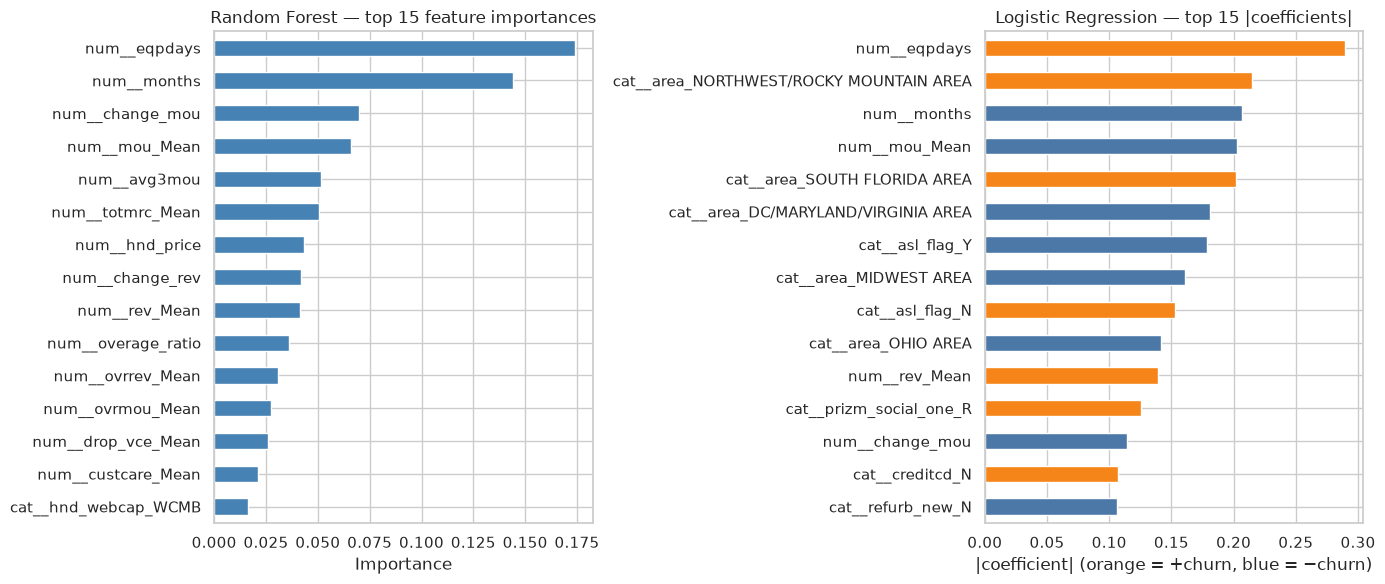

Top RF importances:


,importance
num__eqpdays,0.1738
num__months,0.1442
num__change_mou,0.0698
num__mou_Mean,0.0659
num__avg3mou,0.0513
num__totmrc_Mean,0.0505
num__hnd_price,0.0435
num__change_rev,0.0418
num__rev_Mean,0.0413
num__overage_ratio,0.0358


Top LR coefficients (signed):


,coef
num__eqpdays,0.2896
cat__area_NORTHWEST/ROCKY MOUNTAIN AREA,0.2147
num__months,-0.2066
num__mou_Mean,-0.2025
cat__area_SOUTH FLORIDA AREA,0.2023
cat__area_DC/MARYLAND/VIRGINIA AREA,-0.1811
cat__asl_flag_Y,-0.1787
cat__area_MIDWEST AREA,-0.1610
cat__asl_flag_N,0.1532
cat__area_OHIO AREA,-0.1412


In [ ]:
def get_feature_names(pipe):
    return pipe.named_steps["pre"].get_feature_names_out()


rf_names = get_feature_names(rf_pipe)
rf_imp = pd.Series(
    rf_pipe.named_steps["model"].feature_importances_, index=rf_names
).sort_values(ascending=False)

lr_names = get_feature_names(lr_pipe)
lr_coef = pd.Series(
    lr_pipe.named_steps["model"].coef_.ravel(), index=lr_names
)
lr_top = lr_coef.reindex(lr_coef.abs().sort_values(ascending=False).head(15).index)
lr_ordered = lr_top.reindex(lr_top.abs().sort_values().index)
bar_colors = ["#F58518" if lr_coef[i] > 0 else "#4C78A8" for i in lr_ordered.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rf_imp.head(15).sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Random Forest — top 15 feature importances")
axes[0].set_xlabel("Importance")

lr_ordered.abs().plot.barh(ax=axes[1], color=bar_colors)
axes[1].set_title("Logistic Regression — top 15 |coefficients|")
axes[1].set_xlabel("|coefficient| (orange = +churn, blue = −churn)")
plt.tight_layout()
plt.show()

print("Top RF importances:")
display(rf_imp.head(15).to_frame("importance").round(4))
print("Top LR coefficients (signed):")
display(lr_top.to_frame("coef").round(4))



## 6. Business view — top 10% predicted risk (RF)

Score the test set with the primary model; compare churn rate in the highest-risk decile vs overall (lift).


Test baseline churn rate: 49.560%
Top 10% risk cutoff (RF proba): 0.6164
Customers in top 10%: 2,000 / 20,000
Churn rate in top 10%: 72.850%
Lift vs random: 1.47x


,all_test_mean,top10_mean,diff
eqpdays,392.63,546.99,154.37
hnd_price,102.08,70.76,-31.33
mou_Mean,510.41,319.92,-190.49
change_mou,-12.25,-57.77,-45.52
months,18.85,19.60,0.75
custcare_Mean,1.75,0.50,-1.24


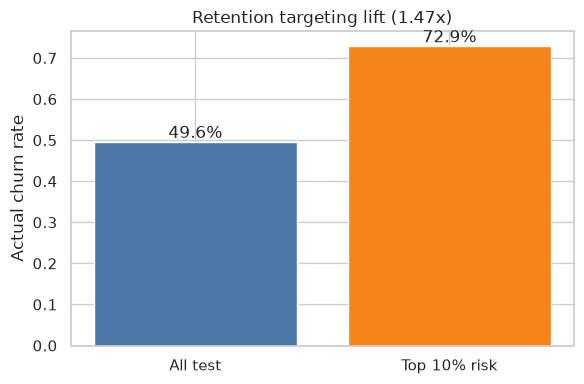

In [ ]:
risk = X_test.copy()
risk["y_true"] = y_test.values
risk["churn_proba"] = rf_proba

cutoff = risk["churn_proba"].quantile(0.90)
top10 = risk[risk["churn_proba"] >= cutoff]
baseline = risk["y_true"].mean()
top_rate = top10["y_true"].mean()
lift = top_rate / baseline if baseline > 0 else np.nan

print(f"Test baseline churn rate: {baseline:.3%}")
print(f"Top 10% risk cutoff (RF proba): {cutoff:.4f}")
print(f"Customers in top 10%: {len(top10):,} / {len(risk):,}")
print(f"Churn rate in top 10%: {top_rate:.3%}")
print(f"Lift vs random: {lift:.2f}x")

compare_cols = ["eqpdays", "hnd_price", "mou_Mean", "change_mou", "months", "custcare_Mean"]
profile = pd.DataFrame(
    {
        "all_test_mean": risk[compare_cols].mean(),
        "top10_mean": top10[compare_cols].mean(),
    }
)
profile["diff"] = profile["top10_mean"] - profile["all_test_mean"]
display(profile.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["All test", "Top 10% risk"], [baseline, top_rate], color=["#4C78A8", "#F58518"])
ax.set_ylabel("Actual churn rate")
ax.set_title(f"Retention targeting lift ({lift:.2f}x)")
for i, v in enumerate([baseline, top_rate]):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()

## 7. Modeling takeaways

1. **EDA → FE:** lean set (~30 cols) keeps handset age, usage change, MRC/overage, and a few segments; drops sparse demographics and redundant lifetime totals.
2. **Preprocessing:** train-only clip on `change_*` / `overage_ratio`; median impute numerics; explicit `Missing` + one-hot for categoricals; `Customer_ID` excluded.
3. **Primary model = Random Forest** because EDA linear associations with churn were weak; trees fit interactions without scaling.
4. **Counterpart = Logistic Regression** for a coefficient-based story — compare AUC/F1 to decide how much non-linearity matters for the write-up.
5. **No SMOTE** — classes are already balanced (~50/50); may be a sampling artifact vs industry rates.
6. **Business hook:** top 10% RF risk should show lift over baseline; profile usually echoes EDA (older `eqpdays`, cheaper handsets, usage decline).
7. **Next (optional):** light hyperparameter search, or XGBoost if RF plateaus — not required for the core assignment path.

Detailed write-ups: [`feature_engineering.md`](feature_engineering.md), [`machine_learning.md`](machine_learning.md).

Column definitions: [`telecom_column_dictionary.md`](telecom_column_dictionary.md).
